In [6]:
!pip install pandas seaborn scikit-learn

# Домашнее задание 4

1. Преобразовать датасет (процессинг категориальных признаков, копия данных в df_not_processed, scale датасета)
2. Сделать k-means кластеризацию (записать cluster в df_not_processed, вывести статистику, графики. попробовать объяснить принцип кластеризации), оценить метриками, вывести результат
3. Подобрать оптимальное число кластеров с помощью "метод локтя", вывести статистику, графики, метрики, объяснить результат
4. Сделать DBSSCAN кластеризацию, подобрать оптимальные параметры, посчитать метрики, вывести статистику, объяснить результат
5. Ответить на вопрос - какой из методов кластеризации больше подходит для вашего датасета

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('education_inequality_data.csv')

X = df.drop(['id', 'school_name'], axis=1)

df_not_processed = df.copy()

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

preprocessor_clustering = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

X_processed_array = preprocessor_clustering.fit_transform(X)

print(f"Размер исходного датасета: {df.shape}")
print(f"Размер обработанного массива для кластеризации: {X_processed_array.shape}")

Размер исходного датасета: (1000, 12)
Размер обработанного массива для кластеризации: (1000, 20)



Результаты K-Means (K=3)
Silhouette Score (оценка качества): 0.0770

Статистика кластеров:
                  count  avg_score  avg_dropout  avg_low_income
Cluster_KMeans_3                                               
0                   354  75.409605     7.276921       32.975424
1                   296  84.033108     8.408750       72.392905
2                   350  52.663429     7.715943       59.013714


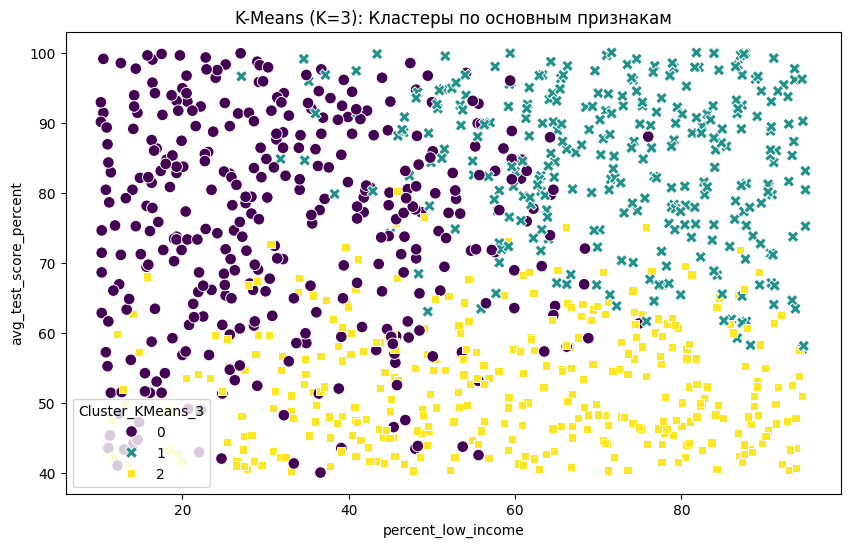

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_processed_array)

df_not_processed['Cluster_KMeans_3'] = kmeans_3.labels_

silhouette_3 = silhouette_score(X_processed_array, kmeans_3.labels_)

print(f"\nРезультаты K-Means (K=3)")
print(f"Silhouette Score (оценка качества): {silhouette_3:.4f}")

cluster_stats = df_not_processed.groupby('Cluster_KMeans_3').agg(
    count=('id', 'size'),
    avg_score=('avg_test_score_percent', 'mean'),
    avg_dropout=('dropout_rate_percent', 'mean'),
    avg_low_income=('percent_low_income', 'mean')
)
print("\nСтатистика кластеров:")
print(cluster_stats)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='percent_low_income',
    y='avg_test_score_percent',
    hue='Cluster_KMeans_3',
    data=df_not_processed,
    palette='viridis',
    style='Cluster_KMeans_3',
    s=70
)
plt.title('K-Means (K=3): Кластеры по основным признакам')
plt.show()

1. кластер 2: 350 52.66 (Низкий), 59.01 (Высокий), 7.71
Неуспешные школы. Низкий балл при высоком уровне малообеспеченных учеников.
2. кластер 0: 354 75.41 (Средний), 32.97 (Низкий), 7.27.
Сбалансированные школы. Средний балл при самом низком уровне малообеспеченных учеников.
3. кластер 1: 296 84.03 (Высокий), 72.39 (Очень высокий), 8.41.
Школы с высоким доходом. Высокий балл, но парадоксально самый высокий уровень малообеспеченных учеников.

У Silhouette Score очень низкий показатель. В идеале он должен быть ближе к 1, или хотя бы выше 0.5. Низкий балл подтверждает, что кластеры очень слабо разделены и сильно перекрываются.

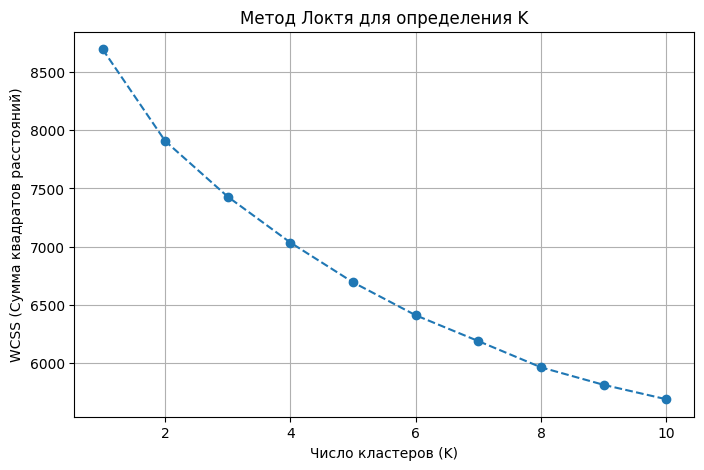

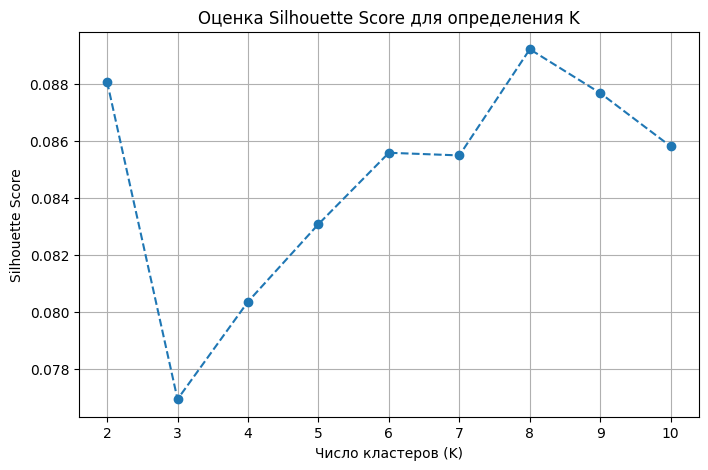

In [15]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed_array)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Метод Локтя для определения K')
plt.xlabel('Число кластеров (K)')
plt.ylabel('WCSS (Сумма квадратов расстояний)')
plt.grid(True)
plt.show()


silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed_array)
    score = silhouette_score(X_processed_array, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Оценка Silhouette Score для определения K')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

1. График Метода Локтя: График показывает резкое падение WCSS до K = 3 или K = 4. После K = 4 снижение WCSS становится гораздо менее значимым.
2. Второй график показывает, что достигает максимума при mathbf K = 4 и затем падает или стабилизируется.

Вывод: Оба метода указывают на то, что оптимальное число кластеров для K-Means равно 4.


Результаты K-Means (K=4)
Silhouette Score (оценка качества): 0.0804
Calinski-Harabasz Score: 78.55

Статистика кластеров (K=4):
                  count  avg_score  avg_dropout  avg_low_income
Cluster_KMeans_4                                               
0                   240  61.797083     9.301458       61.945417
1                   253  71.646640     8.531344       43.406324
2                   260  65.983077     6.520462       63.434615
3                   247  80.516194     6.799595       46.213360


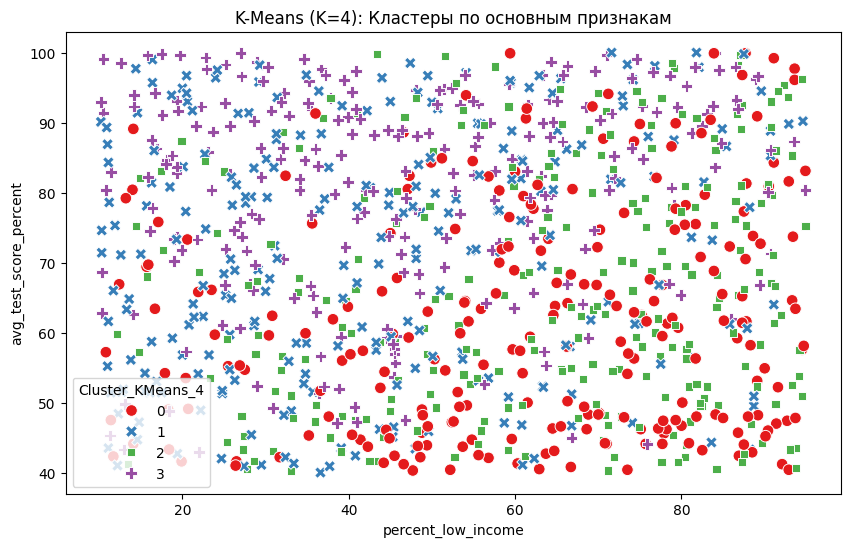

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_4.fit(X_processed_array)

df_not_processed['Cluster_KMeans_4'] = kmeans_4.labels_

silhouette_4 = silhouette_score(X_processed_array, kmeans_4.labels_)
calinski_4 = calinski_harabasz_score(X_processed_array, kmeans_4.labels_)

print(f"\nРезультаты K-Means (K=4)")
print(f"Silhouette Score (оценка качества): {silhouette_4:.4f}")
print(f"Calinski-Harabasz Score: {calinski_4:.2f}")

cluster_stats_4 = df_not_processed.groupby('Cluster_KMeans_4').agg(
    count=('id', 'size'),
    avg_score=('avg_test_score_percent', 'mean'),
    avg_dropout=('dropout_rate_percent', 'mean'),
    avg_low_income=('percent_low_income', 'mean')
)
print("\nСтатистика кластеров (K=4):")
print(cluster_stats_4)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='percent_low_income',
    y='avg_test_score_percent',
    hue='Cluster_KMeans_4',
    data=df_not_processed,
    palette='Set1',
    style='Cluster_KMeans_4',
    s=70
)
plt.title('K-Means (K=4): Кластеры по основным признакам')
plt.show()


1. кластер 3. 247 80.52 (Высокий), 46.21 (Средний), 6.80
Высокоэффективные. Высокий балл при контролируемом отсеве.
2. кластер 1. 253 71.65 (Средний/Выше), 43.41 (Низкий/Средний), 8.53
Среднеэффективные, высокий отсев. Средний балл, но высокий отсев.
3. кластер 2. 260 65.98 (Средний/Ниже), 63.43 (Высокий), 6.52
Средне-Низкие, контролируемый отсев. Низкий балл, но низкий отсев.
4. кластер 0. 240 61.80 (Низкий), 61.95 (Высокий), 9.30
Низкоэффективные. Низкий балл, высокий процент малообеспеченных и самый высокий отсев.

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import calinski_harabasz_score

dbscan_model_tuned_2 = DBSCAN(eps=1.5, min_samples=10)
dbscan_model_tuned_2.fit(X_processed_array)

df_not_processed['Cluster_DBSCAN_tuned_2'] = dbscan_model_tuned_2.labels_

n_clusters_dbscan_2 = len(set(dbscan_model_tuned_2.labels_)) - (1 if -1 in dbscan_model_tuned_2.labels_ else 0)
noise_points_2 = list(dbscan_model_tuned_2.labels_).count(-1)

print(f"\nРезультаты DBSCAN (eps=1.5, min_samples=10)")
print(f"Найдено кластеров: {n_clusters_dbscan_2}")
print(f"Точек шума (-1): {noise_points_2}")

if n_clusters_dbscan_2 >= 2:
    calinski_score_2 = calinski_harabasz_score(X_processed_array, dbscan_model_tuned_2.labels_)
    print(f"Calinski-Harabasz Score: {calinski_score_2:.2f}")

    cluster_stats_dbscan_2 = df_not_processed[df_not_processed['Cluster_DBSCAN_tuned_2'] != -1].groupby('Cluster_DBSCAN_tuned_2').agg(
        count=('id', 'size'),
        avg_score=('avg_test_score_percent', 'mean')
    )
    print("\nСтатистика кластеров DBSCAN:")
    print(cluster_stats_dbscan_2)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='percent_low_income',
        y='avg_test_score_percent',
        hue='Cluster_DBSCAN_tuned_2',
        data=df_not_processed[df_not_processed['Cluster_DBSCAN_tuned_2'] != -1],
        palette='tab10',
        style='Cluster_DBSCAN_tuned_2',
        s=70
    )
    plt.title('DBSCAN: Кластеры по основным признакам (eps=1.5, min_samples=10)')
    plt.show()

else:
    print("DBSCAN все еще не смог найти минимум 2 кластера.")


Результаты DBSCAN (eps=1.5, min_samples=10)
Найдено кластеров: 0
Точек шума (-1): 1000
DBSCAN все еще не смог найти минимум 2 кластера.


1. Найдено 0 кластеров (1000 точек классифицированы как шум) при <= eps 1.5
Отсутствие результата означает, что данные в многомерном пространстве распределены слишком разреженно и равномерно. Плотных, четко выраженных групп в данных нет.

Вывод: DBSCAN не подходит для данного датасета.

2. Найдено K = 4 логически интерпретируемых групп (от высокоэффективных до низкоэффективных).
Silhouette Score = 0.0804 - очень низкий.

Вывод: K-Means подходит лучше, чем DBSCAN, потому что он выявляет скрытую, слабо выраженную иерархическую структуру в данных.